<a href="https://colab.research.google.com/github/ajinfajrian/DataScience_240401020100_Fajrian/blob/master/Pertemuan11_Fajrian_Ichlasul_240401020100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama:** Fajrian Ichlasul Maruto \
**NIM:** 240401020100 \
**Kelas:** IF401 \
**Mata Kuliah:** Data Science \
**Pertemuan 11:** Unsupervised Learning: Clustering

### Import Library & Generate Dataset Sintetis

Tampilan Data Pelanggan Sintetis:


,pendapatan_tahunan,skor_belanja
0,44.021043,8.736520
1,85.073033,89.141535
2,106.814238,59.052331
3,44.507274,86.222877
4,140.101239,56.610216


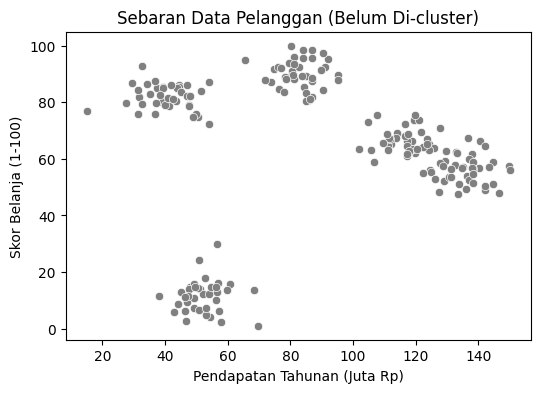

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk Clustering & Preprocessing
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# 1. Generate Data Sintetis (Merepresentasikan 5 tipe pelanggan)
X, y_true = make_blobs(n_samples=200, centers=5, cluster_std=1.0, random_state=42)

# 2. Skalakan nilai agar sesuai instruksi modul (Pendapatan: 15-150, Skor: 1-100)
pendapatan = np.interp(X[:, 0], (X[:, 0].min(), X[:, 0].max()), (15, 150))
skor_belanja = np.interp(X[:, 1], (X[:, 1].min(), X[:, 1].max()), (1, 100))

df = pd.DataFrame({
    'pendapatan_tahunan': pendapatan,
    'skor_belanja': skor_belanja
})

print("Tampilan Data Pelanggan Sintetis:")
display(df.head())

# Visualisasi Data Mentah
plt.figure(figsize=(6, 4))
sns.scatterplot(x='pendapatan_tahunan', y='skor_belanja', data=df, color='gray')
plt.title('Sebaran Data Pelanggan (Belum Di-cluster)')
plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja (1-100)')
plt.show()

### Data Preprocessing (StandardScaler)

In [7]:
# Inisialisasi dan terapkan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("Sampel Data setelah di-Scaling:")
print(X_scaled[:5])

Sampel Data setelah di-Scaling:
[[-1.12096649 -1.87009752]
 [-0.01707538  1.00490653]
 [ 0.56754728 -0.07097887]
 [-1.1078917   0.90054547]
 [ 1.46263723 -0.15830045]]


### Mencari Nilai K Optimal dengan Metode Elbow

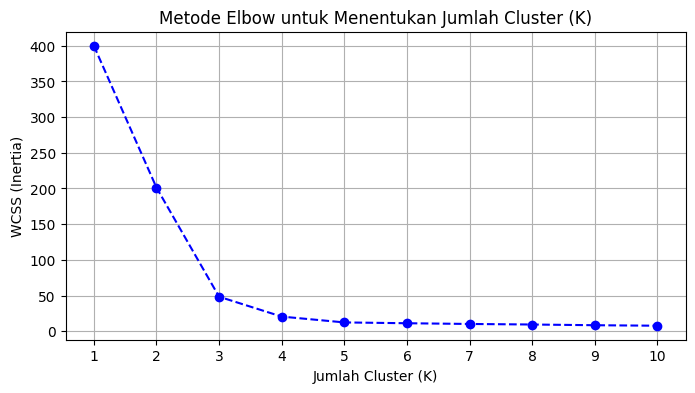

In [8]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # inertia_ adalah nilai WCSS

# Plot Grafik Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster (K)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Dari grafik, terlihat patahan (elbow) paling tajam berada di K = 5.

### Pemodelan 1 - K-Means Clustering

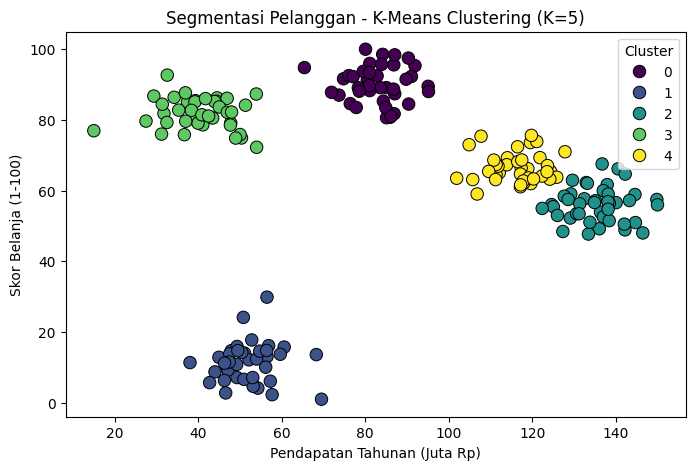

In [9]:
# Inisialisasi dan Fit K-Means
kmeans_model = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_model.fit_predict(X_scaled)

# Visualisasi Hasil K-Means
plt.figure(figsize=(8, 5))
sns.scatterplot(x='pendapatan_tahunan', y='skor_belanja', hue='Cluster_KMeans',
                data=df, palette='viridis', s=80, edgecolor='black')
plt.title('Segmentasi Pelanggan - K-Means Clustering (K=5)')
plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja (1-100)')
plt.legend(title='Cluster')
plt.show()

### Pemodelan 2 - Hierarchical Clustering & Dendrogram

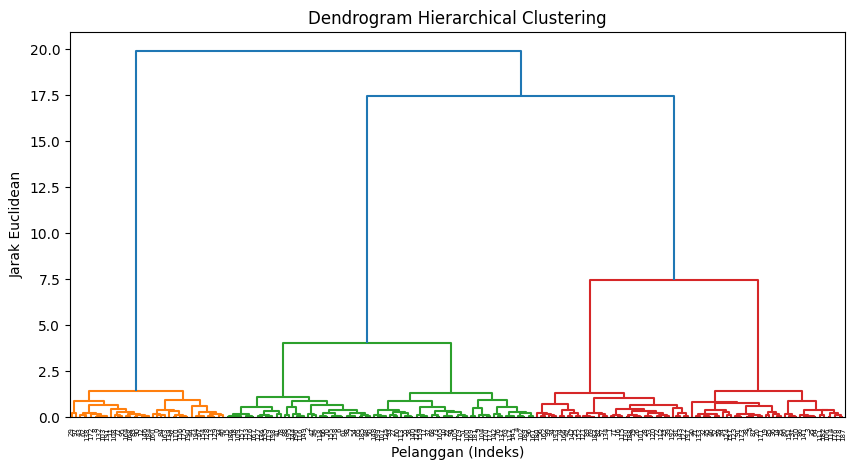

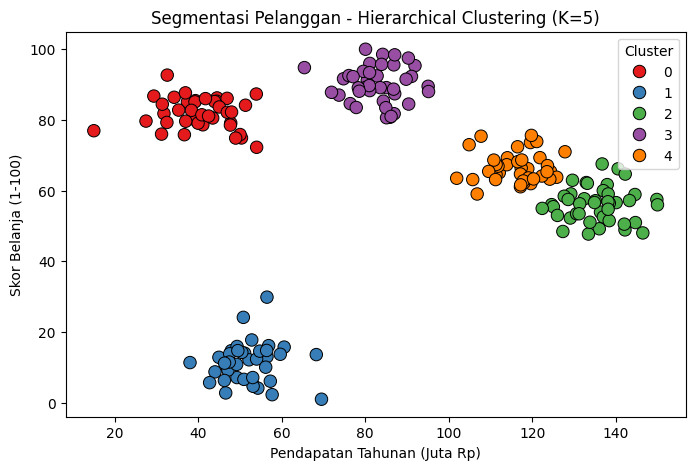

In [10]:
# 1. Membuat Visualisasi Dendrogram
plt.figure(figsize=(10, 5))
plt.title('Dendrogram Hierarchical Clustering')
plt.xlabel('Pelanggan (Indeks)')
plt.ylabel('Jarak Euclidean')
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.show()

# 2. Fit Agglomerative Clustering
hc_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
df['Cluster_Hierarchical'] = hc_model.fit_predict(X_scaled)

# 3. Visualisasi Hasil Hierarchical Clustering
plt.figure(figsize=(8, 5))
sns.scatterplot(x='pendapatan_tahunan', y='skor_belanja', hue='Cluster_Hierarchical',
                data=df, palette='Set1', s=80, edgecolor='black')
plt.title('Segmentasi Pelanggan - Hierarchical Clustering (K=5)')
plt.xlabel('Pendapatan Tahunan (Juta Rp)')
plt.ylabel('Skor Belanja (1-100)')
plt.legend(title='Cluster')
plt.show()

### Kesimpulan Pertemuan 11
* **Apa yang dipelajari:** Mengaplikasikan *Unsupervised Learning* untuk melakukan segmentasi pada pelanggan berbekal algoritma K-Means dan Hierarchical (*Agglomerative*).
* **Temuan utama:** Berdasarkan evaluasi Metode Elbow, jumlah *cluster* yang paling optimal (meminimalkan WCSS secara efisien) adalah 5 kelompok. K-Means dan Hierarchical Clustering menunjukkan pola pengelompokan yang sangat mirip, berhasil memisahkan pelanggan menjadi kategori seperti "Pendapatan Rendah - Belanja Rendah", "Pendapatan Tinggi - Belanja Tinggi", dsb.
* **Tantangan:** Pentingnya penerapan `StandardScaler` sebelum *clustering*, karena algoritma berbasis perhitungan jarak Euclidean (seperti K-Means) akan bias (menghasilkan *cluster* keliru) jika ada fitur yang memiliki rentang nilai dominan.